# GPT-2 Distillation: Alpha and Temperature Sweeps

This notebook runs two small distillation experiments to see how the training objective affects a
GPT-2 student. A frozen GPT-2 small acts as the teacher, and a smaller GPT-2-style student is
trained on WikiText-2. The general combined loss is

```text
loss = alpha * corpus_loss + (1 - alpha) * teacher_loss
```

where `corpus_loss` is cross-entropy against the true next token and `teacher_loss` is the
temperature-scaled KL divergence to the teacher.

We run two sweeps, and to keep the cost low **every student is trained for exactly 5 epochs**:

1. **Temperature sweep** — train a **teacher-only** student (`teacher_loss` alone, no corpus term)
   and vary `T` over `{0.3, 0.5, 0.7, 1, 2}`. Because there is no corpus term, `alpha` does not
   apply here.
2. **Alpha sweep** — use the combined loss, fix `T = 1`, and vary `alpha` over
   `{0, 0.2, 0.5, 0.7, 1}` (`alpha = 1` is corpus only, `alpha = 0` is teacher only).

For each sweep we plot the validation perplexity so the runs can be compared directly.

## 1. Imports and Configuration

In [1]:
import copy
import os
import math
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import GPT2Config, GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt


def set_seed(seed):
    """Make results reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


CFG = {
    # Data
    "dataset_name": "Salesforce/wikitext",
    "dataset_config": "wikitext-2-raw-v1",  # ~2.4M tokens; the only dataset used in this project
    "block_size": 1024,      # tokens per text block
    "batch_size": 16,        # blocks per training step (~32 GB peak VRAM at block_size 1024)

    # Teacher and student model size
    "teacher_name": "gpt2",
    "student_n_layer": 6,
    "student_n_embd": 384,
    "student_n_head": 6,

    # Training
    "seed": 42,
    "lr": 5e-4,
    "sweep_epochs": 4,   # every student in both sweeps trains for exactly this many epochs

    # Set per run by the sweeps below; compute_training_loss reads these from CFG.
    "temperature": 1.0,
    "alpha": 0.5,

    # Sweep 1: teacher-only student, vary temperature (no corpus term, so alpha is unused)
    "temperature_values": [0.3, 0.5, 0.7, 1.0],

    # Sweep 2: fix temperature, vary alpha in the combined loss (alpha weights the corpus
    # term, so alpha=1 is corpus-only and alpha=0 is teacher-only)
    "temperature_fixed": 1.0,
    "alpha_values": [0.0, 0.2, 0.5, 0.7, 1.0],
}

set_seed(CFG["seed"])

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Record the exact stack, which is handy when comparing runs across machines.
import transformers
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
if device == "cuda":
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Using device: cuda
torch 2.9.1+rocm7.2.1 | transformers 5.12.1
GPU 0: AMD Radeon PRO W7900


## 2. Load the Tokenizer

In [2]:
# Load the GPT-2 tokenizer
# tokenized returns token IDs, attention masks, etc. as a dictionary of lists.
tokenizer = GPT2TokenizerFast.from_pretrained(CFG["teacher_name"])

print("Vocabulary size:", tokenizer.vocab_size)
# Quick sanity check: encode then decode a sentence and confirm we get it back.
demo = tokenizer("This project is a demonstration of knowledge distillation for GPT-2")
print("Token IDs:", demo["input_ids"])
print("Decoded   :", tokenizer.decode(demo["input_ids"]))

Vocabulary size: 50257
Token IDs: [1212, 1628, 318, 257, 13646, 286, 3725, 1233, 40903, 329, 402, 11571, 12, 17]
Decoded   : This project is a demonstration of knowledge distillation for GPT-2


## 3. Load & Prepare the Data

We use **`wikitext-2-raw-v1`** for both sweeps and all evaluation. It is about 2.4M GPT-2 tokens,
which is small enough to train each 5-epoch student within a reasonable time budget.

The preparation has three steps:

1. **Tokenize** every line of text into token IDs.
2. **Group into fixed-length blocks** of block_size tokens. Language models train on
   fixed-length sequences, so we concatenate all the tokens into one long stream and then chop
   it into equal chunks. Any leftover tokens that don't fill a full block are dropped.
3. **Create DataLoader** for training, validation and testing

In [3]:
# 1) Download the raw dataset. It has "train", "validation", and "test" sets.
raw_datasets = load_dataset(CFG["dataset_name"], CFG["dataset_config"])
print(raw_datasets)

# 2) Tokenize text in batches.
def tokenize_batch(batch):
    return tokenizer(batch["text"])

tokenized_datasets = raw_datasets.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)
print(tokenized_datasets)

# 3) Join tokenized text together and split it into fixed-size blocks.
block_size = CFG["block_size"]

def group_texts(batch):
    all_input_ids = []

    for token_list in batch["input_ids"]:
        all_input_ids.extend(token_list)

    total_length = (len(all_input_ids) // block_size) * block_size
    blocks = []

    for i in range(0, total_length, block_size):
        blocks.append(all_input_ids[i:i + block_size])

    return {"input_ids": blocks}

lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    remove_columns=tokenized_datasets["train"].column_names,
)
lm_datasets.set_format(type="torch", columns=["input_ids"])

print(lm_datasets)

# 4) Create DataLoaders for each split. Each batch is a tensor with shape (batch_size, block_size).
train_loader = DataLoader(lm_datasets["train"], batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(lm_datasets["validation"], batch_size=CFG["batch_size"])
test_loader = DataLoader(lm_datasets["test"], batch_size=CFG["batch_size"])

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 3760
    })
})
DatasetDict({
    test: Dataset({
        features: ['input_ids'],
        num_rows: 274
    })
    train: Dataset({
        features: ['input_ids'],
        num_rows: 2318
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 240
    })
})


## 4. Load the Teacher (GPT-2 Small)

The teacher is a pretrained GPT-2 small

In [4]:
def count_parameters(model):
    total = 0
    for param in model.parameters():
        total += param.numel()
    return total

# Download/load GPT-2 small.
teacher = GPT2LMHeadModel.from_pretrained(CFG["teacher_name"]).to(device)
teacher.eval()  # freeze behaviour: no dropout, no parameter updates

teacher_params = count_parameters(teacher)
print(f"Teacher: {CFG['teacher_name']}")
print(f"Teacher parameters: {teacher_params}")
print(f"Teacher layers: {teacher.config.n_layer}, hidden size: {teacher.config.n_embd}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Teacher: gpt2
Teacher parameters: 124439808
Teacher layers: 12, hidden size: 768


## 5. Build the Student

Every run in both sweeps uses the **same smaller GPT-2 architecture** and the **same initial
weights**, so the only thing that changes between runs is the loss (the `alpha` and `T` values).
`build_seeded_student()` re-seeds before constructing the model, so each sweep point starts from
byte-identical weights. The student shares the teacher's tokenizer and vocabulary, which is required
for comparing next-token distributions.

In [5]:
def build_student():
    student_config = GPT2Config(
        vocab_size=teacher.config.vocab_size,    # MUST match the teacher,number if tokens in the vocabulary
        n_positions=teacher.config.n_positions,  # max context length (1024)
        n_ctx=teacher.config.n_positions,
        n_embd=CFG["student_n_embd"],            # hidden size (width)
        n_layer=CFG["student_n_layer"],          # number of transformer blocks (depth)
        n_head=CFG["student_n_head"],            # attention heads
        bos_token_id=tokenizer.bos_token_id,     # token ID for the beginning-of-sequence token
        eos_token_id=tokenizer.eos_token_id,     # token ID for the end-of-sequence token
    )
    return GPT2LMHeadModel(student_config).to(device)


def build_seeded_student():
    # Build each student from the same initial weights for a fair comparison.
    set_seed(CFG["seed"])
    return build_student()


# One student here just to report the size; each sweep run rebuilds its own from the same seed.
student_params = count_parameters(build_seeded_student())
print(f"Student parameters: {student_params:,}")
print(f"Student layers: {CFG['student_n_layer']}, hidden size: {CFG['student_n_embd']}")
print(f"Compression ratio (teacher / student): {teacher_params / student_params:.1f}x")

Student parameters: 30,339,456
Student layers: 6, hidden size: 384
Compression ratio (teacher / student): 4.1x


## 6. Distillation Loss

We keep the original method-based loss. It reads `CFG["temperature"]` and `CFG["alpha"]`, and the
`method` argument selects which terms are used:

- `teacher_only`: `total_loss = teacher_loss` (pure KL, no corpus term). The temperature sweep uses
  this, so `alpha` never enters it.
- `combined`: `total_loss = alpha * corpus_loss + (1 - alpha) * teacher_loss`. The alpha sweep uses
  this.
- `corpus_only`: `total_loss = corpus_loss`.

`corpus_loss` is cross-entropy against the true next token; `teacher_loss` is the temperature-scaled
KL divergence to the teacher (logits divided by `T`, then multiplied by `T**2`, the Hinton
correction that keeps the teacher gradient at a comparable strength as `T` changes).

In [6]:
def compute_training_loss(student_logits, teacher_logits, input_ids, method):
    # This function computes the loss for one training batch.

    # student_logits: (batch_size, block_size, vocab_size) tensor of scores for every possible next token
    vocab_size = student_logits.size(-1)

    # GPT predicts the next token, so we compare position 0 with label 1, position 1 with label 2, etc.
    student_next_token_scores = student_logits[:, :-1, :].contiguous()
    true_next_tokens = input_ids[:, 1:].contiguous()

    # Corpus loss: student vs. the real next token from the dataset (cross-entropy expects raw logits).
    corpus_loss = F.cross_entropy(
        student_next_token_scores.view(-1, vocab_size),
        true_next_tokens.view(-1),
    )

    # Teacher loss: student vs. the teacher's full probability distribution.
    teacher_loss = torch.zeros((), device=student_logits.device)
    if teacher_logits is not None:  # no teacher_logits for corpus-only training
        teacher_next_token_scores = teacher_logits[:, :-1, :].contiguous()

        student_log_probs = F.log_softmax(student_next_token_scores / CFG["temperature"], dim=-1)
        teacher_probs = F.softmax(teacher_next_token_scores / CFG["temperature"], dim=-1)

        teacher_loss = F.kl_div(
            student_log_probs.view(-1, vocab_size),
            teacher_probs.view(-1, vocab_size),
            reduction="batchmean",
        ) * (CFG["temperature"] ** 2)

    # Choose which training method this student uses.
    if method == "combined":
        total_loss = CFG["alpha"] * corpus_loss + (1 - CFG["alpha"]) * teacher_loss
    elif method == "corpus_only":
        total_loss = corpus_loss
    elif method == "teacher_only":
        total_loss = teacher_loss
    else:
        raise ValueError(f"Unknown training method: {method}")

    return total_loss, corpus_loss, teacher_loss

## 7. Training

### 7.1 Perplexity Evaluation

Perplexity measures how well the model predicts the next token. It is calculated from the average cross-entropy loss:

```text
perplexity = exp(average cross-entropy loss)
```

In [7]:
def evaluate_perplexity(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)

            # Hugging Face computes the cross-entropy internally when labels are provided.
            # outputs.loss is the average negative log probability of the correct next tokens.
            outputs = model(input_ids=input_ids, labels=input_ids)

            num_tokens = input_ids.size(0) * (input_ids.size(1) - 1)
            total_loss = total_loss + outputs.loss.item() * num_tokens
            total_tokens = total_tokens + num_tokens

    average_loss = total_loss / total_tokens  # average log perplexity
    return math.exp(average_loss)  # convert back to perplexity

### 7.2 Fixed-Length Training

`train_model(model, name, method)` keeps the original method-based interface. It trains for exactly
`CFG["sweep_epochs"]` epochs with **no early stopping**, so every point in a sweep gets the same
budget and the curves are directly comparable. It re-seeds on entry so the data order and dropout
are identical across runs, records validation perplexity after each epoch, and returns that
per-epoch history for plotting. The teacher forward pass runs only when the method needs it
(`teacher_only` or `combined`).

In [8]:
def train_model(model, name, method):
    # Reseed on entry so every run sees the same data order and dropout.
    set_seed(CFG["seed"])

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
    validation_history = []

    for epoch in range(CFG["sweep_epochs"]):
        model.train()
        progress = tqdm(train_loader, desc=f"{name}: epoch {epoch + 1}/{CFG['sweep_epochs']}")

        for batch in progress:
            input_ids = batch["input_ids"].to(device)

            # Run the student to get the logits for every possible next token.
            student_logits = model(input_ids=input_ids).logits

            # Run the teacher only when the method needs teacher guidance.
            teacher_logits = None
            if method in ["combined", "teacher_only"]:
                with torch.no_grad():
                    teacher_logits = teacher(input_ids=input_ids).logits

            loss, corpus_loss, teacher_loss = compute_training_loss(
                student_logits, teacher_logits, input_ids, method,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            progress.set_postfix(loss=f"{loss.item():.3f}")

        validation_ppl = evaluate_perplexity(model, val_loader)
        validation_history.append(validation_ppl)
        print(f"{name} validation perplexity after epoch {epoch + 1}: {validation_ppl:.2f}")

    print(f"Finished training {name} model.")

    del model
    if device == "cuda":
        torch.cuda.empty_cache()
    return validation_history

## 8. Experiment 1 — Temperature Sweep (teacher only)

Train a **teacher-only** student for each `T` in `{0.3, 0.5, 0.7, 1, 2}`, 5 epochs each. The loss is
pure KL to the teacher, so there is no corpus term and `alpha` plays no role. This isolates the
effect of temperature and shows whether sharpening (`T < 1`) or softening (`T > 1`) the teacher
helps.

In [9]:
temperature_results = {}
for T in CFG["temperature_values"]:
    print(f"\n=== Temperature sweep (teacher only): T={T} ===")
    CFG["temperature"] = T                       # compute_training_loss reads this
    student = build_seeded_student()             # same initial weights every run
    temperature_results[T] = train_model(student, name=f"T={T}", method="teacher_only")

temperature_final = {T: hist[-1] for T, hist in temperature_results.items()}
best_T = min(temperature_final, key=temperature_final.get)

print("\nFinal validation perplexity by temperature (teacher only):")
for T in CFG["temperature_values"]:
    print(f"  T = {T}: {temperature_final[T]:.2f}")
print(f"Best temperature: T = {best_T} ({temperature_final[best_T]:.2f})")


=== Temperature sweep (teacher only): T=0.3 ===


T=0.3: epoch 1/4:   0%|          | 0/145 [00:00<?, ?it/s]

c:\Users\Ethan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\Ethan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Using AOTriton backend for Efficient Attention backward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention_backward.hip:551.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


T=0.3 validation perplexity after epoch 1: 5607.18


T=0.3: epoch 2/4:   0%|          | 0/145 [00:00<?, ?it/s]

...

T=1.0 validation perplexity after epoch 2: 478.31


T=1.0: epoch 3/4:   0%|          | 0/145 [00:00<?, ?it/s]

T=1.0 validation perplexity after epoch 3: 382.62


T=1.0: epoch 4/4:   0%|          | 0/145 [00:00<?, ?it/s]

T=1.0 validation perplexity after epoch 4: 311.71
Finished training T=1.0 model.

Final validation perplexity by temperature (teacher only):
  T = 0.3: 2969.94
  T = 0.5: 1163.54
  T = 0.7: 542.64
  T = 1.0: 311.71
Best temperature: T = 1.0 (311.71)


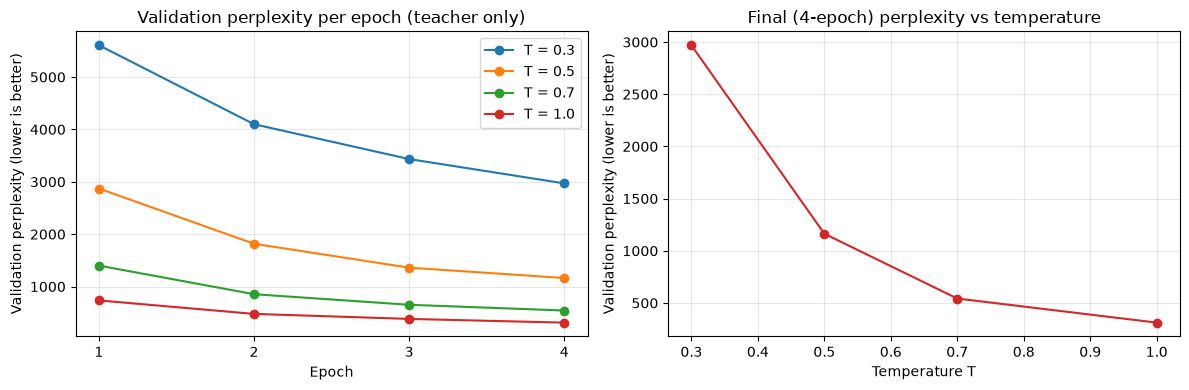

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_axis = range(1, CFG["sweep_epochs"] + 1)

# Left: validation perplexity per epoch, one curve per temperature.
for T in CFG["temperature_values"]:
    axes[0].plot(epochs_axis, temperature_results[T], marker="o", label=f"T = {T}")
axes[0].set_title("Validation perplexity per epoch (teacher only)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation perplexity (lower is better)")
axes[0].set_xticks(list(epochs_axis))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right: final (epoch-5) validation perplexity vs temperature.
temps = CFG["temperature_values"]
axes[1].plot(temps, [temperature_final[T] for T in temps], marker="o", color="C3")
axes[1].set_title(f"Final ({CFG['sweep_epochs']}-epoch) perplexity vs temperature")
axes[1].set_xlabel("Temperature T")
axes[1].set_ylabel("Validation perplexity (lower is better)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Experiment 2 — Alpha Sweep (T = 1)

Fix `T = 1` and train one student for each `alpha` in `{0, 0.2, 0.5, 0.7, 1}`, 5 epochs each.
Recall `alpha` weights the corpus term, so `alpha = 1` is corpus only and `alpha = 0` is teacher
only. This shows how much hard-label grounding helps relative to the teacher signal.

In [11]:
alpha_results = {}
CFG["temperature"] = CFG["temperature_fixed"]     # T = 1 for the whole alpha sweep
for a in CFG["alpha_values"]:
    print(f"\n=== Alpha sweep (combined): alpha={a}, T={CFG['temperature']} ===")
    CFG["alpha"] = a                              # compute_training_loss reads this
    student = build_seeded_student()              # same initial weights every run
    alpha_results[a] = train_model(student, name=f"alpha={a}", method="combined")

alpha_final = {a: hist[-1] for a, hist in alpha_results.items()}
best_alpha = min(alpha_final, key=alpha_final.get)

print("\nFinal validation perplexity by alpha (T = 1):")
for a in CFG["alpha_values"]:
    print(f"  alpha = {a}: {alpha_final[a]:.2f}")
print(f"Best alpha: alpha = {best_alpha} ({alpha_final[best_alpha]:.2f})")


=== Alpha sweep (combined): alpha=0.0, T=1.0 ===


alpha=0.0: epoch 1/4:   0%|          | 0/145 [00:00<?, ?it/s]

alpha=0.0 validation perplexity after epoch 1: 735.69


alpha=0.0: epoch 2/4:   0%|          | 0/145 [00:00<?, ?it/s]

alpha=0.0 validation perplexity after epoch 2: 478.31


...

alpha=1.0 validation perplexity after epoch 2: 589.39


alpha=1.0: epoch 3/4:   0%|          | 0/145 [00:00<?, ?it/s]

alpha=1.0 validation perplexity after epoch 3: 450.70


alpha=1.0: epoch 4/4:   0%|          | 0/145 [00:00<?, ?it/s]

alpha=1.0 validation perplexity after epoch 4: 386.43
Finished training alpha=1.0 model.

Final validation perplexity by alpha (T = 1):
  alpha = 0.0: 311.80
  alpha = 0.2: 342.94
  alpha = 0.5: 371.17
  alpha = 0.7: 414.19
  alpha = 1.0: 386.43
Best alpha: alpha = 0.0 (311.80)


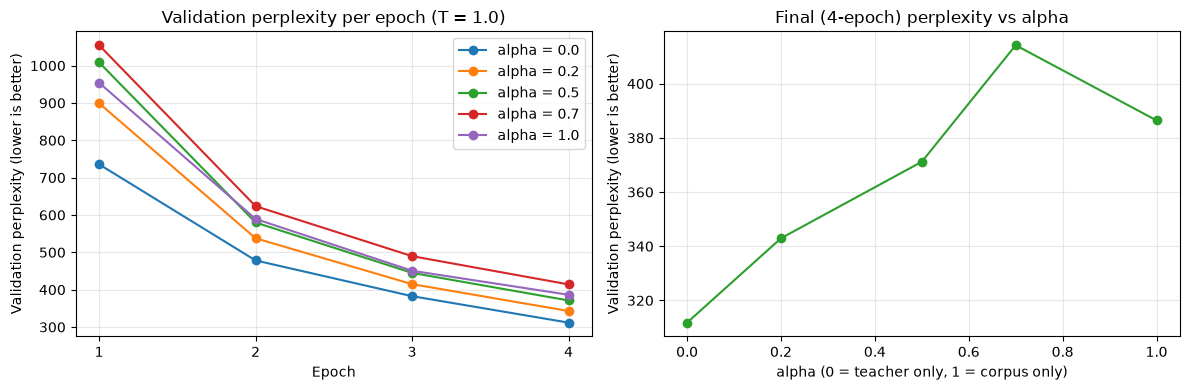

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_axis = range(1, CFG["sweep_epochs"] + 1)

# Left: validation perplexity per epoch, one curve per alpha.s
for a in CFG["alpha_values"]:
    axes[0].plot(epochs_axis, alpha_results[a], marker="o", label=f"alpha = {a}")
axes[0].set_title(f"Validation perplexity per epoch (T = {CFG['temperature_fixed']})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation perplexity (lower is better)")
axes[0].set_xticks(list(epochs_axis))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right: final (epoch-5) validation perplexity vs alpha.
alphas = CFG["alpha_values"]
axes[1].plot(alphas, [alpha_final[a] for a in alphas], marker="o", color="C2")
axes[1].set_title(f"Final ({CFG['sweep_epochs']}-epoch) perplexity vs alpha")
axes[1].set_xlabel("alpha (0 = teacher only, 1 = corpus only)")
axes[1].set_ylabel("Validation perplexity (lower is better)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()